In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
url = "https://raw.githubusercontent.com/plotly/datasets/master/supermarket_Sales.csv"
df = pd.read_csv(url)

df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,Cost of goods sold,Gross margin percentage,Gross income,Customer stratification rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [3]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
df.info()

Shape: (1000, 17)

Columns:
 Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Total', 'Date',
       'Time', 'Payment', 'Cost of goods sold', 'Gross margin percentage',
       'Gross income', 'Customer stratification rating'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Invoice ID                      1000 non-null   object 
 1   Branch                          1000 non-null   object 
 2   City                            1000 non-null   object 
 3   Customer type                   1000 non-null   object 
 4   Gender                          1000 non-null   object 
 5   Product line                    1000 non-null   object 
 6   Unit price                      1000 non-null   float64
 7   Quantity      

In [4]:
df.isnull().sum()

Invoice ID                        0
Branch                            0
City                              0
Customer type                     0
Gender                            0
Product line                      0
Unit price                        0
Quantity                          0
Tax 5%                            0
Total                             0
Date                              0
Time                              0
Payment                           0
Cost of goods sold                0
Gross margin percentage           0
Gross income                      0
Customer stratification rating    0
dtype: int64

In [5]:
df.describe()

,Unit price,Quantity,Tax 5%,Total,Cost of goods sold,Gross margin percentage,Gross income,Customer stratification rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1.000000e+03,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905e+00,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,6.131498e-14,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905e+00,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905e+00,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905e+00,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905e+00,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905e+00,49.650000,10.00000


In [6]:
for col in df.columns:
    print(col, ":", df[col].dtype)

Invoice ID : object
Branch : object
City : object
Customer type : object
Gender : object
Product line : object
Unit price : float64
Quantity : int64
Tax 5% : float64
Total : float64
Date : object
Time : object
Payment : object
Cost of goods sold : float64
Gross margin percentage : float64
Gross income : float64
Customer stratification rating : float64


In [7]:
# Convert 'Date' to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Convert categorical columns
categorical_cols = ['Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Payment']
for col in categorical_cols:
    df[col] = df[col].astype('category')

df.dtypes

Invoice ID                                object
Branch                                  category
City                                    category
Customer type                           category
Gender                                  category
Product line                            category
Unit price                               float64
Quantity                                   int64
Tax 5%                                   float64
Total                                    float64
Date                              datetime64[ns]
Time                                      object
Payment                                 category
Cost of goods sold                       float64
Gross margin percentage                  float64
Gross income                             float64
Customer stratification rating           float64
dtype: object

In [8]:
# Normalize Total column
df['Total_norm'] = (df['Total'] - df['Total'].min()) / (df['Total'].max() - df['Total'].min())

df[['Total', 'Total_norm']].head()

,Total,Total_norm
0,548.9715,0.521616
1,80.2200,0.067387
2,340.5255,0.319628
3,489.0480,0.463549
4,634.3785,0.604377


In [9]:
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

df_encoded.head()

,Invoice ID,Unit price,Quantity,Tax 5%,Total,Date,Time,Cost of goods sold,Gross margin percentage,Gross income,...,City_Yangon,Customer type_Normal,Gender_Male,Product line_Fashion accessories,Product line_Food and beverages,Product line_Health and beauty,Product line_Home and lifestyle,Product line_Sports and travel,Payment_Credit card,Payment_Ewallet
0,750-67-8428,74.69,7,26.1415,548.9715,2019-01-05,13:08,522.83,4.761905,26.1415,...,True,False,False,False,False,True,False,False,False,True
1,226-31-3081,15.28,5,3.8200,80.2200,2019-03-08,10:29,76.40,4.761905,3.8200,...,False,True,False,False,False,False,False,False,False,False
2,631-41-3108,46.33,7,16.2155,340.5255,2019-03-03,13:23,324.31,4.761905,16.2155,...,True,True,True,False,False,False,True,False,True,False
3,123-19-1176,58.22,8,23.2880,489.0480,2019-01-27,20:33,465.76,4.761905,23.2880,...,True,False,True,False,False,True,False,False,False,True
4,373-73-7910,86.31,7,30.2085,634.3785,2019-02-08,10:37,604.17,4.761905,30.2085,...,True,True,True,False,False,False,False,True,False,True


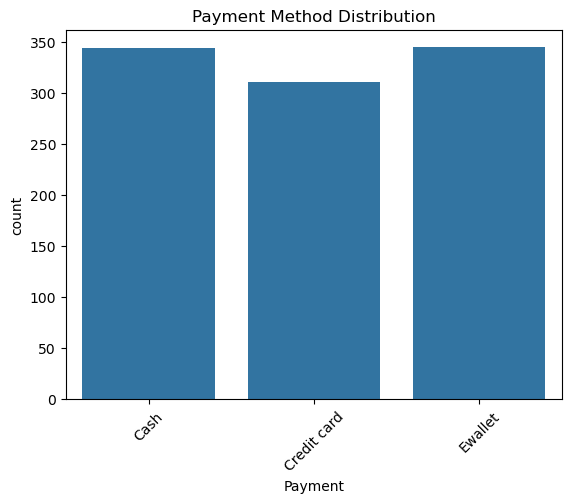

In [10]:
sns.countplot(x='Payment', data=df)
plt.title("Payment Method Distribution")
plt.xticks(rotation=45)
plt.show()

In [11]:
print("Data Wrangling Completed Successfully on Supermarket Dataset")


Data Wrangling Completed Successfully on Supermarket Dataset
